# TRUST Additional Validation Data

## First combine data from genotypic samples and patients

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq
from evcouplings.align import Alignment

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

# if len(solo_results) == 1:
#     solo_results = solo_results[list(solo_results.keys())[0]]

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

In [2]:
def combine_TRUST_patient_samples(df_trust_patients, df_trust):

    print(f"{len(df_trust_patients.patient_num.unique())} patients in TRUST/data_20230825.csv")
    
    # each sample ID is in the format like 260-04, S0299-01	, or S0271-01A. So use re to remove all alpha characters and keep only numbers.
    # first number is the patient number, second is the sample number
    df_trust["patient_num"] = [int(re.findall(r'\d+', val.split("-")[0])[0]) for val in df_trust["original ID"].values]
    df_trust["sample_week"] = [int(re.findall(r'\d+', val.split("-")[1])[0]) for val in df_trust["original ID"].values]

    # keep only samples for the patients in df_trust_patients
    #df_trust_report = df_trust_report.query("patient_num in @df_trust_patients.patient_num.unique()")
    df_trust = df_trust.merge(df_trust_patients[["pid", "patient_num"]], on="patient_num", how="inner")
    print(f"Found {len(df_trust.patient_num.unique())}/{len(df_trust_patients.patient_num.unique())} patients in TRUST/2023-01-24_report_Farhat.v09.xlsx")
    
    # rename some columns that have spaces in them
    df_trust = df_trust.rename(columns={"Cov Any Mean": "Cov_Any_Mean",
                                        "Cov Unam Perc": "Cov_Unam_Perc",
                                        "Perc. Reads Mapped": "Perc_Reads_Mapped",
                                        "original ID": "original_ID",
                                        "phylogenetic classification (Coll et al., 2014)": "Coll2014_Annotated"
                                       })

    df_trust["Coll2014"] = [val.split(" ")[0] for val in df_trust["Coll2014_Annotated"].values]
    df_trust["Lineage"] = [val.split(".")[0] for val in df_trust["Coll2014"].values]

    # get VCF file paths
    df_trust = df_trust.reset_index(drop=True)
    
    for i, row in df_trust.iterrows():

        sample_id = row["SampleID"]

        # two directories in which they could be. Ignore the direct from sputum sequencing directory, that is for a different project
        possible_fNames = [
            f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/220617.TRUST.Set1.Illumina.Output/{sample_id}/IlluminaWGS/Pilon_IlluminaPE_AlignedTo_H37rv_minMQ_1_minDP_5_Fix_All_Breaks/{sample_id}.IllPE.H37rv.vcf.gz",
                           f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/221216.TRUST.Illumina.Batch2.Output/{sample_id}/IlluminaWGS/Pilon_IlluminaPE_AlignedTo_H37rv_minMQ_1_minDP_5_Fix_All_Breaks/{sample_id}.IllPE.H37rv.vcf.gz",
                          ]

        found_vcf_file = False
        
        for fName in possible_fNames:
            if os.path.isfile(fName):
                df_trust.loc[i, "VCF"] = fName
                found_vcf_file = True
                break

        if not found_vcf_file:
            print(f"VCF file for {sample_id} not found!")

    # also remove contaminated samples
    print(df_trust.comment.value_counts())
    return df_trust.query("comment == '-'")

In [3]:
df_trust_patients = pd.read_csv("TRUST/data_20230825.csv")
df_trust_patients["patient_num"] = [int(patient_id.replace("T0", "")) for patient_id in df_trust_patients["pid"].values]

trust_report = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/2023-01-24_report_Farhat.v09.xlsx", sheet_name=None)
df_trust_report = trust_report["summary"]

In [4]:
df_trust = combine_TRUST_patient_samples(df_trust_patients, df_trust_report)
df_trust.to_csv("TRUST/combined_samples_patients.csv", index=False)

df_trust = pd.read_csv("TRUST/combined_samples_patients.csv")
print(df_trust.shape)

154 patients in TRUST/data_20230825.csv
Found 154/154 patients in TRUST/2023-01-24_report_Farhat.v09.xlsx
comment
-                       257
heavily contaminated      3
contaminated              2
Name: count, dtype: int64
(257, 17)


# Create summary figure of the MICs of the 4 first-line drugs (these are the only MICs that were tested)

In [5]:
highQual_pheno_cols = []

for col in df_trust_patients.columns[df_trust_patients.columns.str.contains('mic_sputum_specimen')]:

    not_null = len(df_trust_patients.loc[~pd.isnull(df_trust_patients[col])])

    # at least 75% not null. PZA very low (49%), but the model is bad anyway, so it's fine
    if not_null / len(df_trust_patients) > 0.25:
        print(col, not_null / len(df_trust_patients))
        highQual_pheno_cols.append(col)

TRUST_phenos = df_trust_patients[["pid"] + highQual_pheno_cols]#.dropna(axis=0)
print(f"{len(TRUST_phenos)} patients with MICs")

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '<=25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

TRUST_phenos = TRUST_phenos.melt(id_vars="pid")

s_inhmic_sputum_specimen_1 0.9545454545454546
s_rifmic_sputum_specimen_1 0.9545454545454546
s_embmic_sputum_specimen_1 0.9545454545454546
s_pzamic_sputum_specimen_1 0.5974025974025974
154 patients with MICs


In [6]:
TRUST_plot_phenos = pd.DataFrame(TRUST_phenos[["variable", "value"]].query("variable.str.contains('sputum')").value_counts()).reset_index()

TRUST_plot_phenos.columns = ["Drug", "MIC_group", "Count"]

TRUST_plot_phenos["Drug"] = TRUST_plot_phenos["Drug"].replace("s_embmic_sputum_specimen_1", "Ethambutol"
                                                    ).replace("s_rifmic_sputum_specimen_1", "Rifampicin",
                                                    ).replace("s_inhmic_sputum_specimen_1", "Isoniazid",
                                                    ).replace("s_pzamic_sputum_specimen_1", "Pyrazinamide")

In [9]:
def create_stacked_percent_bar_chart(df, x_order, palettes, index_var="Drug", col_var="MIC_group", count_var="Count", saveName=None):
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    df_stacked_for_plotting = df.pivot(index=index_var, columns=col_var, values=count_var).fillna(0).astype(int)
    df_stacked_for_plotting["Total"] = df_stacked_for_plotting.sum(axis=1)

    # compute proportions for plotting
    for group in df[col_var].unique():
        df_stacked_for_plotting[group] = df_stacked_for_plotting[group] / df_stacked_for_plotting["Total"]
        
    del df_stacked_for_plotting["Total"]
    df_stacked_for_plotting = df_stacked_for_plotting.reset_index().melt(id_vars=index_var)
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(df_stacked_for_plotting[index_var].unique()))
    
    # order in increasing lineage abundance for each drug
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([index_var, "value"], ascending=[True, False])

    # add string labels to the dataframe. Use these to label the bar segments with
    for i, row in df_stacked_for_plotting.iterrows():
    
        if row["Drug"] == "Rifampicin":
            df_stacked_for_plotting.loc[i, "Label"] = RIF_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Isoniazid":
            df_stacked_for_plotting.loc[i, "Label"] = INH_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Ethambutol":
            df_stacked_for_plotting.loc[i, "Label"] = EMB_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Pyrazinamide":
            df_stacked_for_plotting.loc[i, "Label"] = PZA_label_encoding_dict[row[col_var]]
        else:
            raise ValueError(f"{row['Drug']} is not a valid drug name!")

    # reorder the dataframe to match the plotting order so that we can add bar labels properly
    # Convert the 'Category' column to Categorical data type with the desired order
    df_stacked_for_plotting[f'{col_var}_categorical'] = pd.Categorical(df_stacked_for_plotting[index_var], categories=x_order, ordered=True)
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([col_var, f'{col_var}_categorical']).reset_index(drop=True)
    
    # iterate through the Lineages and convert to percentages
    column_groups = df_stacked_for_plotting[col_var].unique()
    
    for i, column_group in enumerate(column_groups):  
                        
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_group].groupby(index_var)["value"].sum().reset_index()
        single_group = single_group.set_index(index_var).loc[x_order, :].reset_index()
        
        if i > 0:
            prev_vals = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_groups[i-1]].groupby(index_var)["value"].sum().reset_index()
            prev_vals = prev_vals.set_index(index_var).loc[x_order, :].reset_index()["value"].values 
            prev_vals_array += prev_vals
            
        ax.bar(single_group[index_var].values, 
               single_group["value"].values, 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=column_group,
               width=0.5
              )       
    
    label_loc = 'center'
    sigfig = 2
    font_size = '7'

    # Get the patches from ax
    patches = ax.get_children()
    rect_patches = [patch for patch in patches if isinstance(patch, plt.Rectangle)]
    
    # variable to iterate over the product of len(col_var) * len(index_var). In this case, = 15
    count_idx = -1
    num_drugs = len(x_order)
    # len(ax.containers) = the number of unique values in col_var
    for cont in ax.containers:
        
        labels = []

        # len(cont) = the number of unique values in index_var
        for val in cont.datavalues:

            # iterate for every value
            count_idx += 1

            # update the patch color
            use_palette = palettes[count_idx % num_drugs]
            new_color = use_palette[count_idx // num_drugs]
            rect_patches[count_idx].set_facecolor(new_color)
            
            if val > 0.025:
                labels.append(df_stacked_for_plotting["Label"].values[count_idx])
            else:
                labels.append("")

        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)

    # fig.canvas.draw()

    text = ax.text(
        x=1,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>0.2',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    plt.xticks(fontsize="8")
    plt.yticks(fontsize="7")
    plt.ylabel("Proportion", fontsize="8")
    plt.setp(ax.patches, linewidth=0.75)
    plt.ylim(0, 1.025)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return df_stacked_for_plotting.reset_index(drop=True)

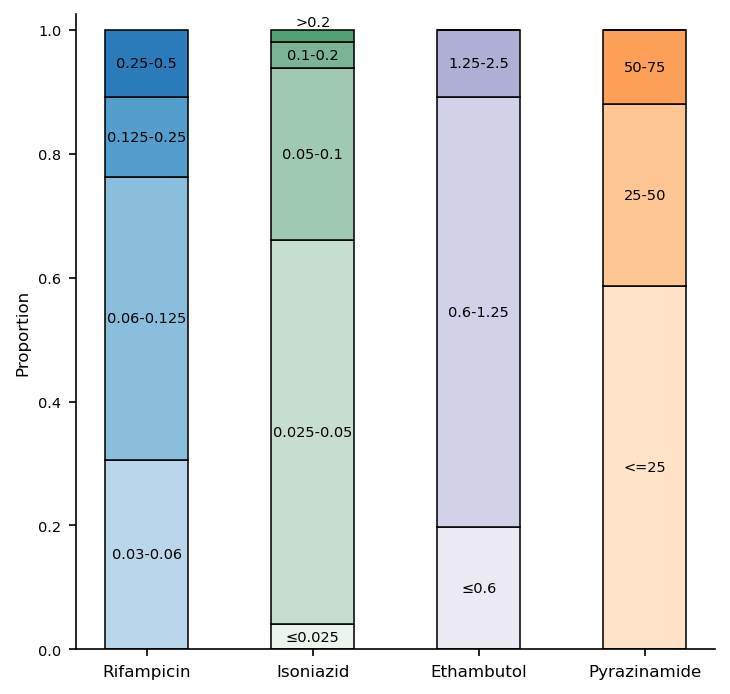

In [13]:
index_var = "Drug"
col_var = "MIC_group"
count_var = "Count"
x_order = ["Rifampicin", "Isoniazid", "Ethambutol", "Pyrazinamide"]

df_stacked_for_plotting = create_stacked_percent_bar_chart(TRUST_plot_phenos, 
                                                           x_order, 
                                                           palettes=[sns.color_palette("Blues").as_hex(),
                                                                     sns.light_palette("seagreen").as_hex(),
                                                                     sns.color_palette("Purples").as_hex(),
                                                                     sns.color_palette("Oranges").as_hex(),
                                                                    ],
                                                           index_var="Drug", 
                                                           col_var="MIC_group", 
                                                           count_var="Count",
                                                           saveName="TRUST/phenos_barchart.png"
                                                          )

In [12]:
len(TRUST_plot_phenos)

15

# Check if the VCF files for different samples associated to the same patient are different

In [16]:
samples_per_patient = pd.DataFrame(df_trust.groupby("pid")["SampleID"].transform(lambda x: ",".join(x)))
samples_per_patient["pid"] = df_trust["pid"].values
print(samples_per_patient.shape)
samples_per_patient = samples_per_patient.drop_duplicates("pid")
print(samples_per_patient.shape)

(257, 2)
(154, 2)


In [13]:
# multisamples = []

# for i, row in samples_per_patient.iterrows():

#     if "," in row["SampleID"]:
#         samples_lst = row["SampleID"].split(",")
#         multisamples.append(len(samples_lst))

#         for sample in samples_lst:

#             vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{sample}.vcf")

#             for record in vcf_reader:

#                 if record.POS >= 759611	and record.POS <= 767320:
#                     print(row["pid"], sample, record)
                    
#         print("\n")

In [14]:
# np.unique(multisamples, return_counts=True)

In [14]:
def get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict):

    MIC_encoding_dict_rev = {val: key for key, val in MIC_encoding_dict.items()}

    df_TRUST_predict = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/validation/TRUST/MIC_predictions.csv")

    # keep the earliest sample
    df_TRUST_predict = df_TRUST_predict.merge(df_trust, on="SampleID", how="left").sort_values("sample_week", ascending=True).drop_duplicates("pid")
    
    # keep only patients with MIC measured from a sputum sample
    df_patients = df_trust_patients.loc[~pd.isnull(df_trust_patients[f"s_{drug.lower()}mic_sputum_specimen_1"])]

    bounds_df = pd.DataFrame(df_patients[f"s_{drug.lower()}mic_sputum_specimen_1"].map(MIC_encoding_dict).str.split(",", expand=True))
    bounds_df.columns = [f"{drug}_lower_bound", f"{drug}_upper_bound"]
    bounds_df[f"s_{drug.lower()}mic_sputum_specimen_1"] = df_patients[f"s_{drug.lower()}mic_sputum_specimen_1"]
    bounds_df = pd.concat([df_patients[["pid"]], bounds_df], axis=1)
    
    bounds_df[[f"{drug}_lower_bound", f"{drug}_upper_bound"]] = bounds_df[[f"{drug}_lower_bound", f"{drug}_upper_bound"]].astype(float)
    bounds_df[f"{drug}_midpoint"] = (bounds_df[f"{drug}_lower_bound"] + bounds_df[f"{drug}_upper_bound"]) / 2
    
    # for i, row in bounds_df.iterrows():
    #     if row[f"{drug}_upper_bound"] > 1000:
    #         bounds_df.loc[i, f"{drug}_midpoint"] = row[f"{drug}_lower_bound"]

    # bounds_df = bounds_df.merge(df_TRUST_predict, on="pid", how="inner")
    # bounds_df["CNN_MIC_group"] = bounds_df[f"s_{drug.lower()}mic_sputum_specimen_1"].map(MIC_encoding_dict_rev)
    return bounds_df.merge(df_TRUST_predict, on="pid", how="inner")

In [33]:
def compare_predicted_actual_MIC(drug, model_path, MIC_encoding_dict, label_encoding_dict, palette="Blues", model="CNN", saveName=None):

    if model not in ["CNN", "Reg"]:
        raise ValueError(f"{model} must be 'CNN' or 'Reg'")
        
    df_patient_data = get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict)
    # print(df_patient_data.shape)

    mic_col = f"MIC_{model}"
    plot_col = "pred_MIC_group"
    
    for group, bounds_str in MIC_encoding_dict.items():
    
        lower_bound, upper_bound = np.array(bounds_str.split(",")).astype(float)
        df_patient_data.loc[(df_patient_data[mic_col] > lower_bound) & (df_patient_data[mic_col] <= upper_bound), plot_col] = group

    var1_categories = df_patient_data[f"s_{drug.lower()}mic_sputum_specimen_1"].unique()
    var2_categories = df_patient_data[plot_col].unique()
    categories = list(set(var1_categories).union(var2_categories))

    overlap = pd.crosstab(df_patient_data[f"s_{drug.lower()}mic_sputum_specimen_1"], df_patient_data[plot_col])

    # reverse the y-ticks (index) because by default they are increasing DOWN, but we want them to increase UP
    overlap = overlap.reindex(index=categories[::-1], columns=categories, fill_value=0)
    
    # Create the heatmap
    fig, ax = plt.subplots()
    sns.heatmap(overlap, annot=True, cmap=palette, linewidths=0.25, linecolor="black", ax=ax, clip_on=False, fmt='g')
    
    old_labels = [float(val.get_text()) for val in ax.get_xticklabels()]
    new_labels = pd.Series(old_labels).map(label_encoding_dict)
    
    ax.set_xticks(ticks=ax.get_xticks(), labels=new_labels, fontsize="9")

    # reverse the y-ticks because by default they are increasing DOWN, but we want them to increase UP
    ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels[::-1], rotation=0, fontsize="9")
    
    plt.xlabel("\nPredicted MIC (µg/mL)", fontsize="10")
    plt.ylabel("Actual MIC (µg/mL)", fontsize="10")
    
    sns.despine()

    predicted_correct = df_patient_data.query(f"s_{drug.lower()}mic_sputum_specimen_1 == {plot_col}").shape[0]
    predicted_EA = df_patient_data.query(f"~((s_{drug.lower()}mic_sputum_specimen_1 - {plot_col} > 1) | ({plot_col} - s_{drug.lower()}mic_sputum_specimen_1 > 1))").shape[0]

    plt.title(f"Categorical Accuracy: {np.round(predicted_correct / len(df_patient_data), 2)}\nEsssential Agreement: {np.round(predicted_EA / len(df_patient_data), 2)}")

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300, bbox_inches="tight")
        
    return df_patient_data

# Rifampicin

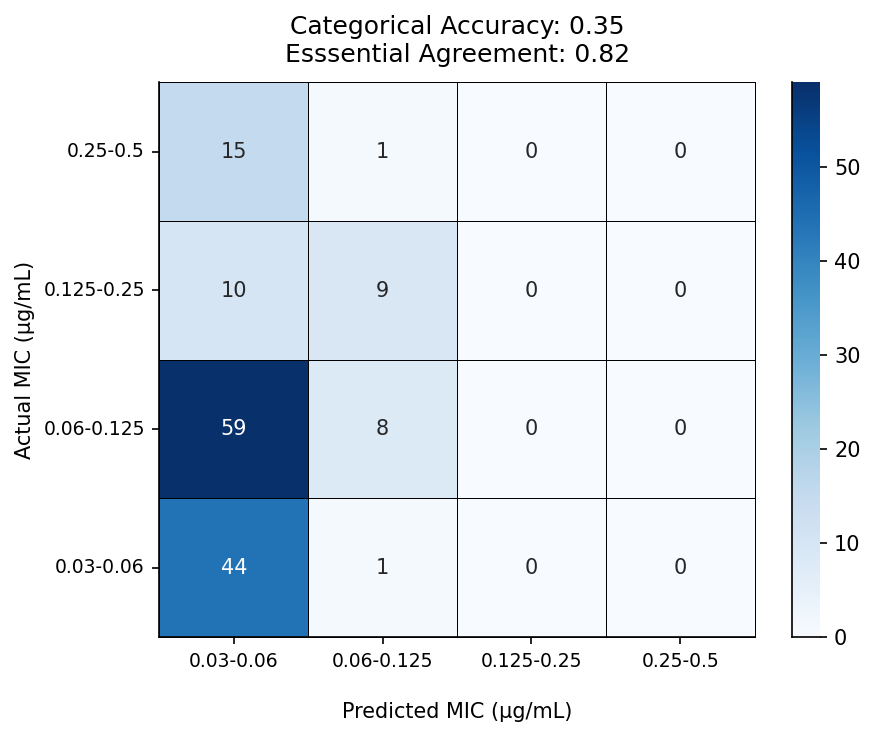

In [34]:
# WITHOUT LINEAGE
RIF_MIC_encoding_dict = {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,100000'}
RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}

drug = "RIF"
model_path = "RIF_rpoABC"

_ = compare_predicted_actual_MIC(drug, model_path, RIF_MIC_encoding_dict, RIF_label_encoding_dict, palette=sns.color_palette("Blues", as_cmap=True), model="CNN", saveName="Rifampicin/validation/TRUST_CNN_predictions_heatmap.png")

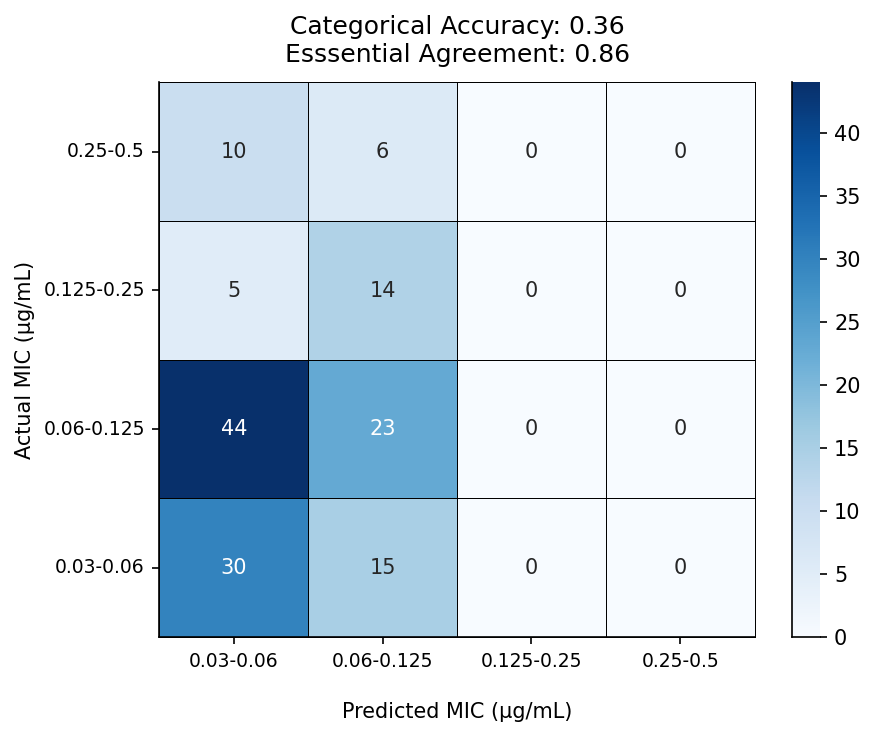

In [35]:
# WITHOUT LINEAGE
RIF_MIC_encoding_dict = {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,100000'}
RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}

drug = "RIF"
model_path = "RIF_rpoABC"

_ = compare_predicted_actual_MIC(drug, model_path, RIF_MIC_encoding_dict, RIF_label_encoding_dict, palette=sns.color_palette("Blues", as_cmap=True), model="Reg", saveName="Rifampicin/validation/TRUST_Reg_predictions_heatmap.png")

# Isoniazid

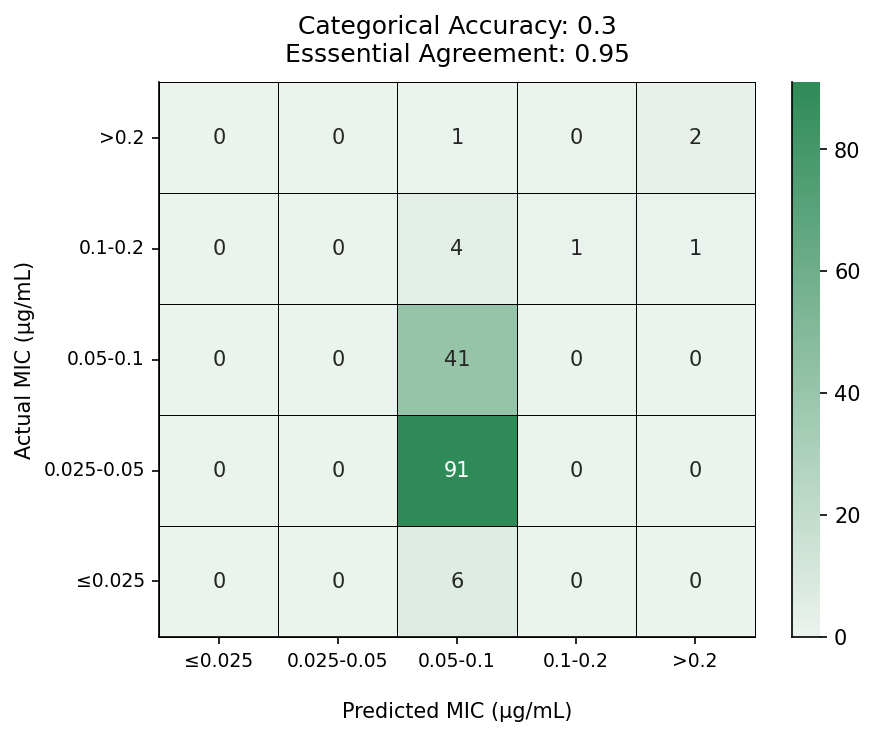

In [36]:
# WITH LINEAGE
INH_MIC_encoding_dict = {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,100000'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}

drug = "INH"
model_path = "INH_4Loci"

_ = compare_predicted_actual_MIC(drug, model_path, INH_MIC_encoding_dict, INH_label_encoding_dict, palette=sns.light_palette("seagreen", as_cmap=True), model="CNN", saveName="Isoniazid/validation/TRUST_CNN_predictions_heatmap.png")

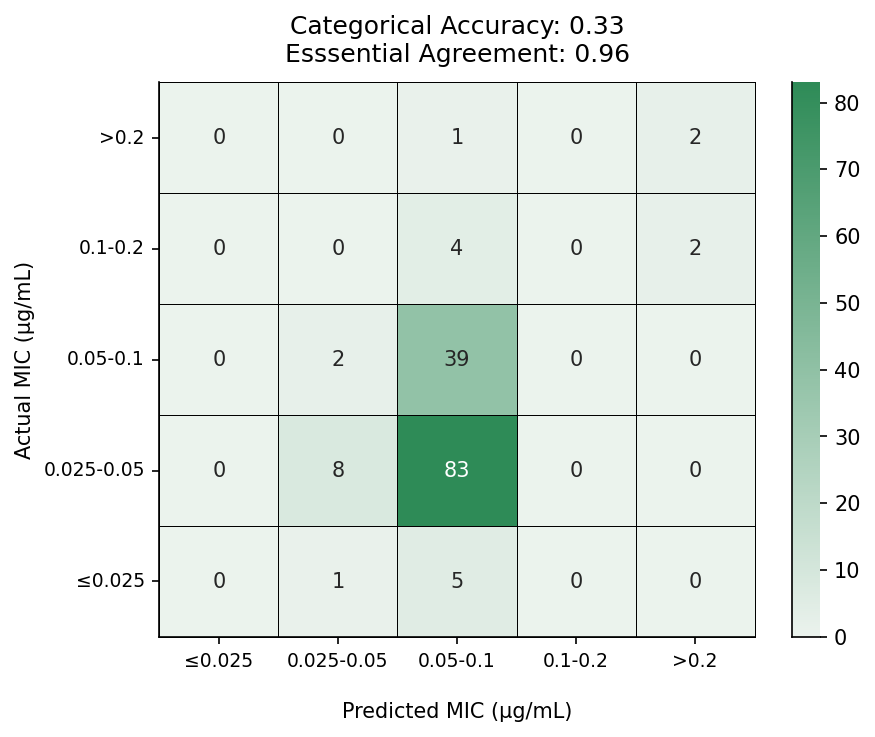

In [37]:
drug = "INH"
model_path = "INH_4Loci"

_ = compare_predicted_actual_MIC(drug, model_path, INH_MIC_encoding_dict, INH_label_encoding_dict, palette=sns.light_palette("seagreen", as_cmap=True), model="Reg", saveName="Isoniazid/validation/TRUST_Reg_predictions_heatmap.png")

# Ethambutol

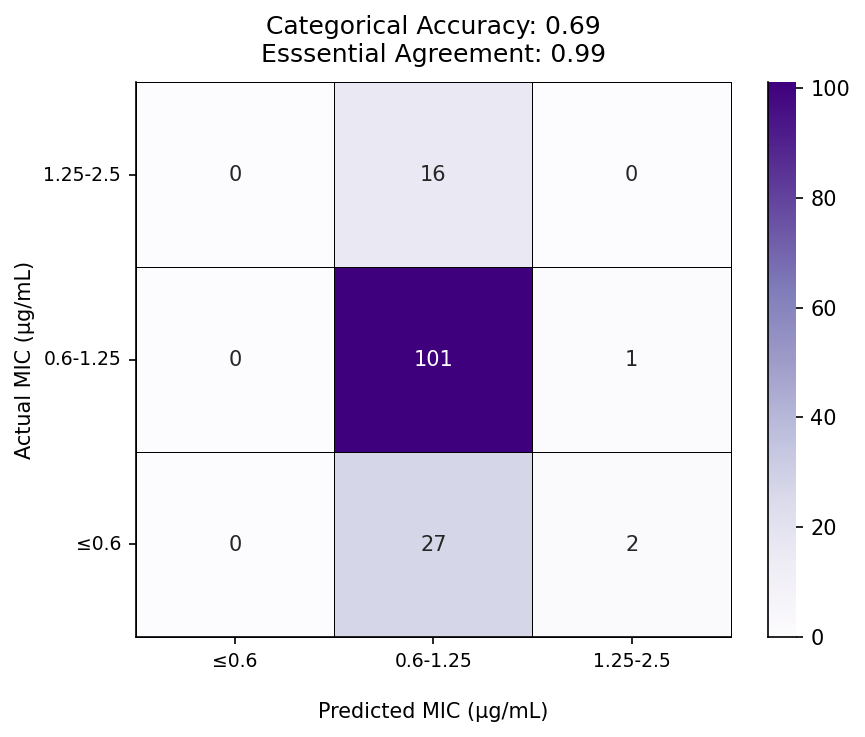

In [38]:
# WITHOUT LINEAGE
EMB_MIC_encoding_dict = {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,100000'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}

drug = "EMB"
model_path = "EMB_2Loci"

_ = compare_predicted_actual_MIC(drug, model_path, EMB_MIC_encoding_dict, EMB_label_encoding_dict, palette=sns.color_palette("Purples", as_cmap=True), model="CNN", saveName="Ethambutol/validation/TRUST_CNN_predictions_heatmap.png")

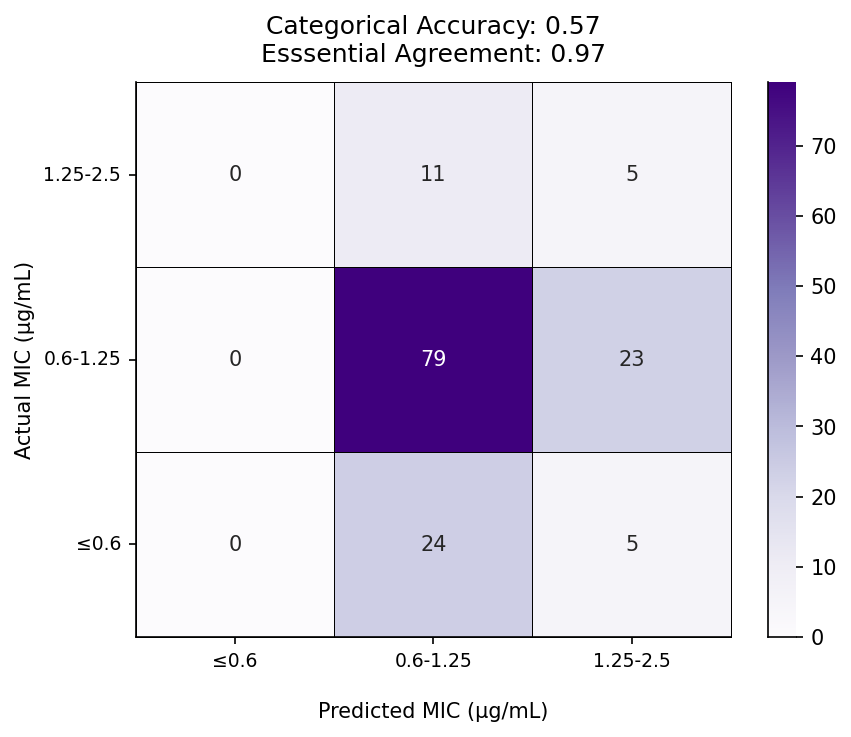

In [39]:
drug = "EMB"
model_path = "EMB_2Loci"

_ = compare_predicted_actual_MIC(drug, model_path, EMB_MIC_encoding_dict, EMB_label_encoding_dict, palette=sns.color_palette("Purples", as_cmap=True), model="Reg", saveName="Ethambutol/validation/TRUST_Reg_predictions_heatmap.png")

# Pyrazinamide

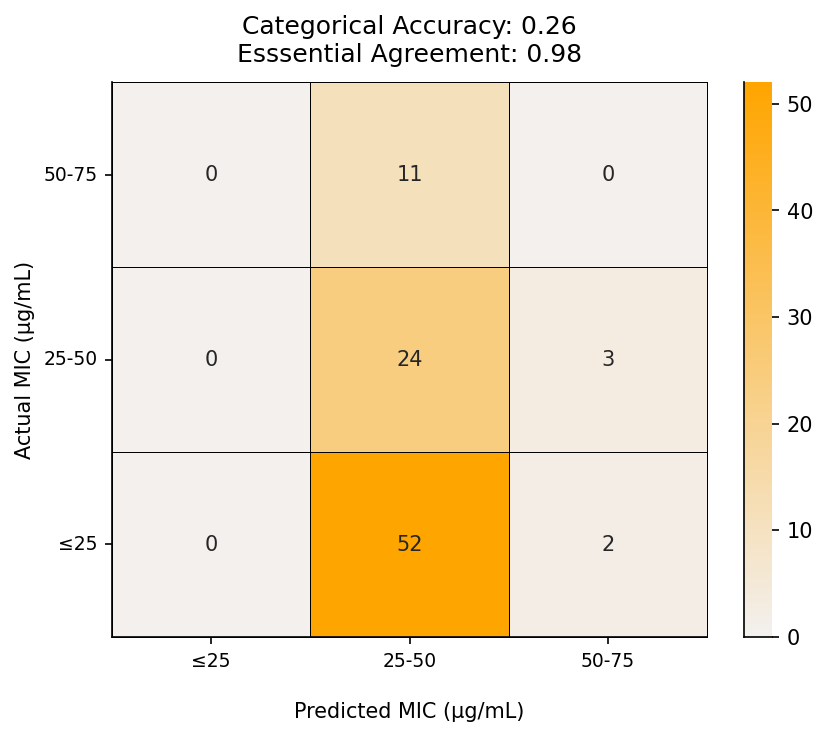

In [40]:
PZA_MIC_encoding_dict = {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,100000'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

drug = "PZA"
model_path = "PZA_4Loci"

_ = compare_predicted_actual_MIC(drug, model_path, PZA_MIC_encoding_dict, PZA_label_encoding_dict, palette=sns.light_palette("orange", as_cmap=True), model="CNN", saveName="Pyrazinamide/validation/TRUST_CNN_predictions_heatmap.png")

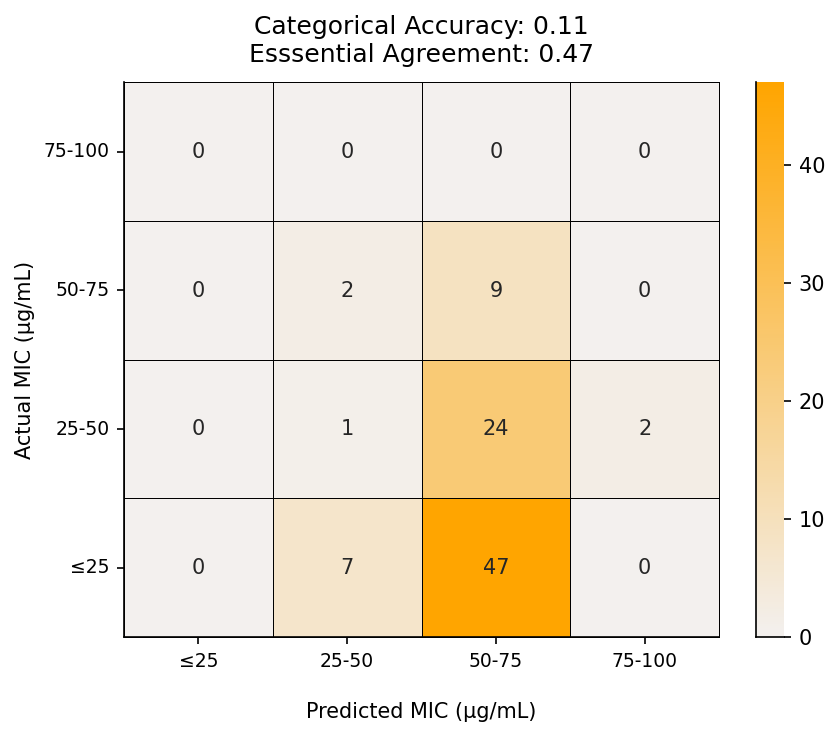

In [41]:
PZA_MIC_encoding_dict = {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,100000'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

drug = "PZA"
model_path = "PZA_4Loci"

_ = compare_predicted_actual_MIC(drug, model_path, PZA_MIC_encoding_dict, PZA_label_encoding_dict, palette=sns.light_palette("orange", as_cmap=True), model="Reg", saveName="Pyrazinamide/validation/TRUST_Reg_predictions_heatmap.png")

# Summary of Essential Agreements Across Drugs

In [45]:
df_EA = pd.DataFrame({"Drug": ["Rifampicin"]*2 + ["Isoniazid"]*2 + ["Ethambutol"]*2 + ["Pyrazinamide"]*2,
                      "Model": ["CNN", "LinReg"]*4,
                     "EA": np.array([0.793, 0.333, 0.946, 0.063, 0.991, 0.793, 0.983, 0.224])*100
                    })

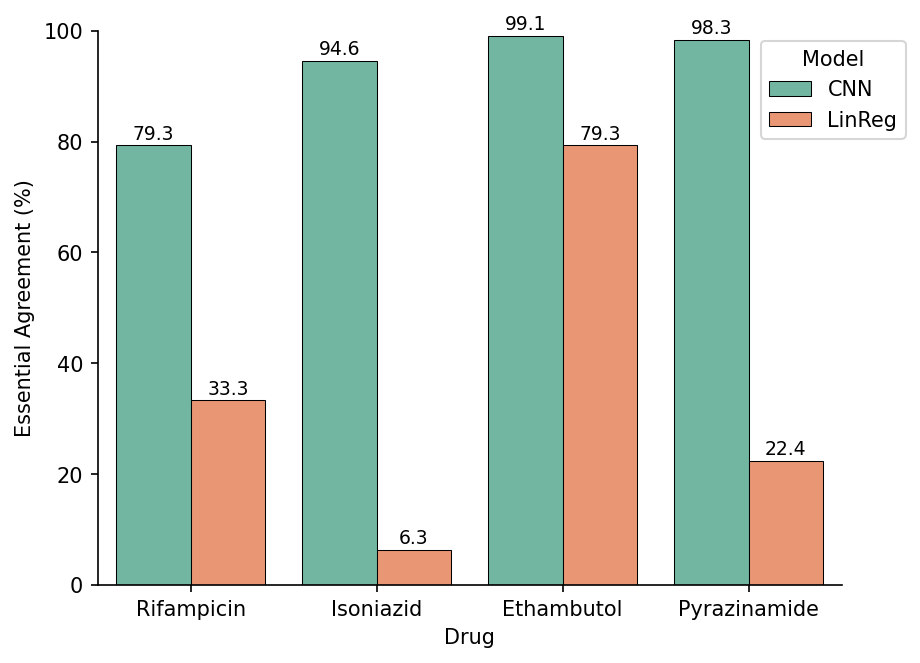

In [46]:
fig, ax = plt.subplots()

sns.barplot(data=df_EA,
             x="Drug",
             y="EA",
             hue="Model",
             palette=sns.color_palette("Set2"),
             edgecolor="black",
             linewidth=0.5,
             ax=ax
            )

for i in range(len(ax.containers)):

    size = 9
    ax.bar_label(ax.containers[i], #fmt=f"%.{sigfig}f", 
                 fontsize=size, label_type="edge", padding=1)

sns.move_legend(ax, "upper right", bbox_to_anchor=(1.1, 1))
plt.ylabel("Essential Agreement (%)")
plt.ylim(0, 100)
sns.despine()
plt.show()
#plt.savefig("TRUST/EA_comparison.png", dpi=300)